In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
file_path = "/content/drive/MyDrive/emails.csv"  # change if inside a folder
df = pd.read_csv(file_path)

df.head()


# Clean text column
df["processed_text"] = df["processed_text"].fillna("").astype(str)

# Clean numeric features
numeric_features = [
    "keyword_count",
    "text_length",
    "word_count",
    "avg_word_length",
    "url_count",
    "email_count",
    "exclamation_count",
    "question_count",
    "dollar_count"
]

df[numeric_features] = df[numeric_features].fillna(0)

# Define X and y
X = df[["processed_text"] + numeric_features]
y = df["label"]


In [14]:
text_feature = "processed_text"



X = df[[text_feature] + numeric_features]
y = df["label"]


In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(max_features=5000), text_feature),
        ("num", StandardScaler(), numeric_features)
    ]
)



In [16]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000),
                                                  'processed_text'),
                                                 ('num', StandardScaler(),
                                                  ['keyword_count',
                                                   'text_length', 'word_count',
                                                   'avg_word_length',
                                                   'url_count', 'email_count',
                                                   'exclamation_count',
                                                   'question_count',
                                                   'dollar_count'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [19]:
import pickle

drive_path = "/content/drive/MyDrive/phishing_pipeline.pkl"

with open(drive_path, "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved to Google Drive successfully!")
from google.colab import files

files.download(drive_path)


Model saved to Google Drive successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]


In [21]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9624362758250604


In [22]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.96      0.97      2265
           1       0.94      0.96      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



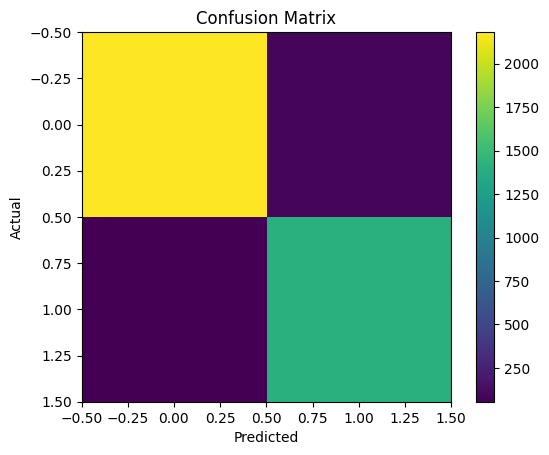

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()


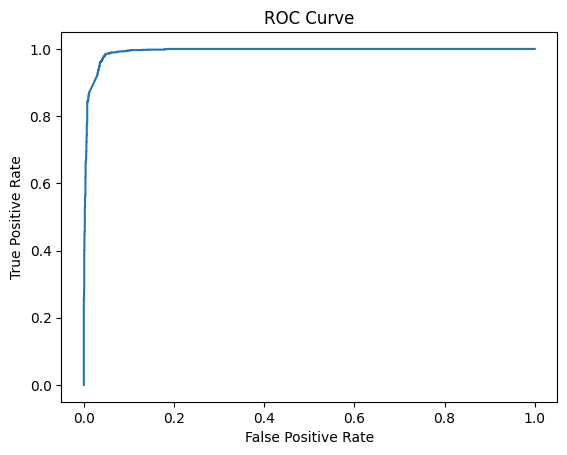

ROC-AUC: 0.9928979323132301


In [24]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("ROC-AUC:", roc_auc)
